In [ ]:
import json

# Load input JSON
with open('/content/pitch_sequences.json', 'r') as f:
    data = json.load(f)

grouped_cents = []

for recording_instances in data.values():
    for instance in recording_instances:
        cents = [point["pitch_cents"] for point in instance.get("pitch_data", [])]
        grouped_cents.append(cents)

# Save result
with open('only_pitch_cents_grouped.json', 'w') as f:
    json.dump(grouped_cents, f, indent=2)


In [ ]:
import json

def process_pitch_cents(input_file, output_file):
    # Load the JSON file
    with open(input_file, "r") as file:
        data = json.load(file)

    print(f"Total sequences: {len(data)}")
    processed_data = []

    for sequence in data:  # Each sequence is just a list of pitch_cents
        # Remove zero-pitch values
        filtered_sequence = [pitch for pitch in sequence if pitch != 0]

        if not filtered_sequence:
            print("Filtered sequence is empty!")

        # Generate input-output pairs
        for i in range(len(filtered_sequence) - 30):
            input_seq = filtered_sequence[i:i + 30]  # Numerical values
            output_pitch = filtered_sequence[i + 30]  # Numerical value
            processed_data.append({"input": input_seq, "output": output_pitch})

    if len(processed_data) == 0:
        print("No input-output pairs were generated!")

    # Save the processed dataset
    with open(output_file, "w") as outfile:
        json.dump(processed_data, outfile, indent=4)

    print(f"Processed data saved to {output_file}")

# Example usage
input_file = "only_pitch_cents_grouped.json"  # Use your actual file path
output_file = "processed_pitch_dataset.json"
process_pitch_cents(input_file, output_file)


Total sequences: 21
Processed data saved to processed_pitch_dataset.json


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import json
import numpy as np
from torch.utils.data import Dataset, DataLoader

# ==== 🔹 Step 1: Load Preprocessed JSON Data ====
with open("/content/processed_pitch_dataset.json", "r") as f:
    data = json.load(f)

# Extract input-output sequences
X = np.array([seq["input"] for seq in data], dtype=np.float32)  # Shape: (num_samples, 10)
Y = np.array([seq["output"] for seq in data], dtype=np.float32).reshape(-1, 1)  # Shape: (num_samples, 1)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)  # (batch_size, seq_len)
Y_tensor = torch.tensor(Y, dtype=torch.float32)  # (batch_size, 1)

# ==== 🔹 Step 2: Dataset & DataLoader ====
class PitchDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataset = PitchDataset(X_tensor, Y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# ==== 🔹 Step 3: Transformer Model Definition ====
class PitchTransformer(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, num_layers):
        super(PitchTransformer, self).__init__()
        self.embedding = nn.Linear(1, embed_dim)  # Embed each pitch value (scalar → vector)

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)

        self.decoder = nn.Linear(embed_dim, 1)

    def forward(self, x):
        # x: (batch_size, seq_len) → (batch_size, seq_len, 1)
        x = x.unsqueeze(-1)
        x = self.embedding(x)            # (batch_size, seq_len, embed_dim)
        x = self.transformer_encoder(x)  # (batch_size, seq_len, embed_dim)
        x = x[:, -1, :]                  # Use the last time step's output
        return self.decoder(x)          # (batch_size, 1)

# ==== 🔹 Step 4: Model Setup ====
seq_len = 30
embed_dim = 64
num_heads = 4
ff_dim = 128
num_layers = 3

model = PitchTransformer(embed_dim=embed_dim, num_heads=num_heads, ff_dim=ff_dim, num_layers=num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==== 🔹 Step 5: Training Loop ====
num_epochs = 5
for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, Y_batch in dataloader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs.squeeze(), Y_batch.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {total_loss / len(dataloader):.4f}")

# ==== 🔹 Step 6: Save the Trained Model ====
torch.save(model.state_dict(), "pitch_transformer.pth")


Epoch 1, Loss: 2192187.4861
Epoch 2, Loss: 2047184.1827
Epoch 3, Loss: 1819608.5743
Epoch 4, Loss: 1537838.5209
Epoch 5, Loss: 1240937.1094


In [ ]:
import numpy as np
import torch

def generate_sancaras(model, input_seq, num_sancaras=4, length=100, temperature=1.5):
    model.eval()
    sancaras = []

    for _ in range(num_sancaras):
        generated_seq = list(input_seq)

        for _ in range(length):
            input_tensor = torch.tensor(
                [generated_seq[-10:]], dtype=torch.float32  # Shape: (1, seq_len)
            )

            with torch.no_grad():
                output = model(input_tensor).item()

            # 🔥 Temperature scaling
            scaled_output = output / temperature

            # Slight smoothing with previous pitch
            if len(generated_seq) > 1:
                scaled_output = (
                    0.7 * generated_seq[-1] + 0.3 * scaled_output
                )

            # 🎲 Add randomness to avoid repetition
            scaled_output += np.random.uniform(-2, 2)

            # Optional: clip to typical pitch range (in cents)
            scaled_output = np.clip(scaled_output, 400, 800)

            generated_seq.append(scaled_output)

        sancaras.append(np.array(generated_seq))

    return sancaras

# Example usage
generated_sancaras = generate_sancaras(model, X[0][:10], num_sancaras=4, length=100, temperature=1.5)

# Print one example
print("Generated Sancara 1:", generated_sancaras[0])


Generated Sancara 1: [1160.0151  1150.0151  1140.0151  1130.0149  1120.015   1110.0149
 1100.0149  1080.0148  1070.0148  1070.0148   800.       658.8114
  561.06323  493.3551   447.4032   411.7372   400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.       400.       400.
  400.       400.       400.       400.  

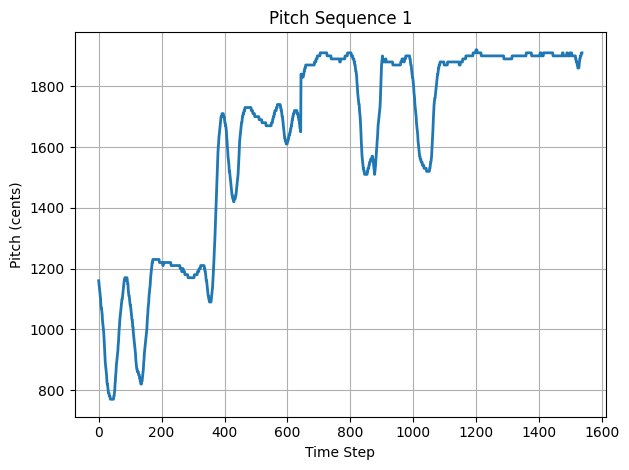

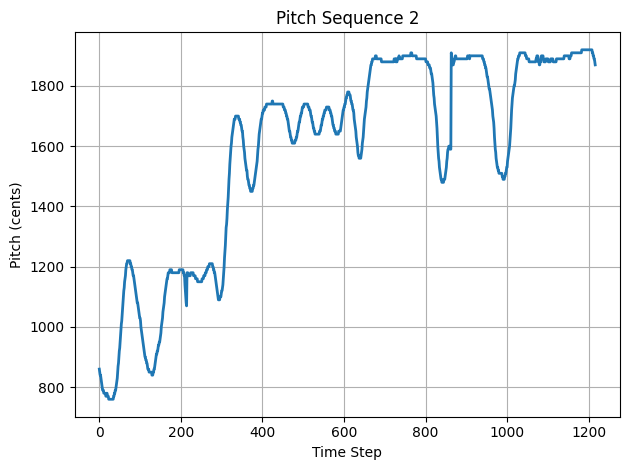

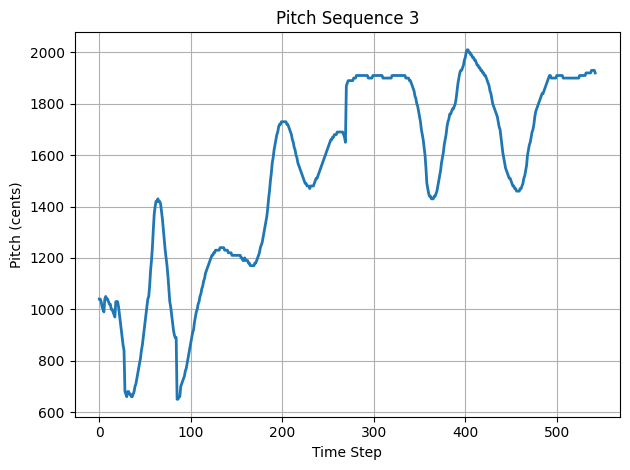

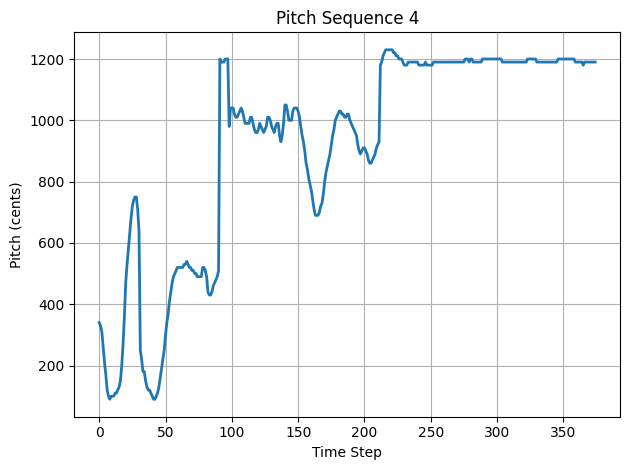

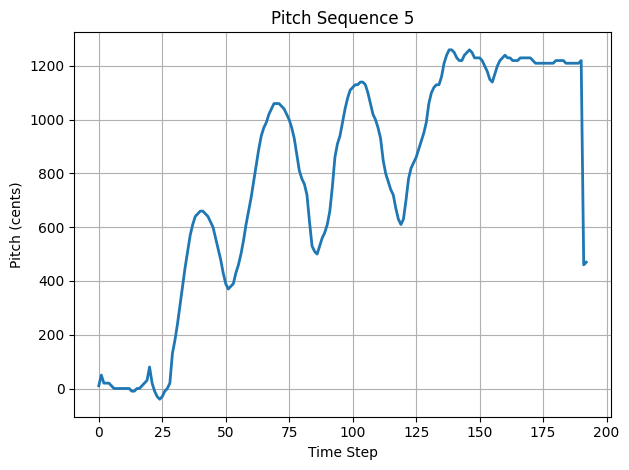

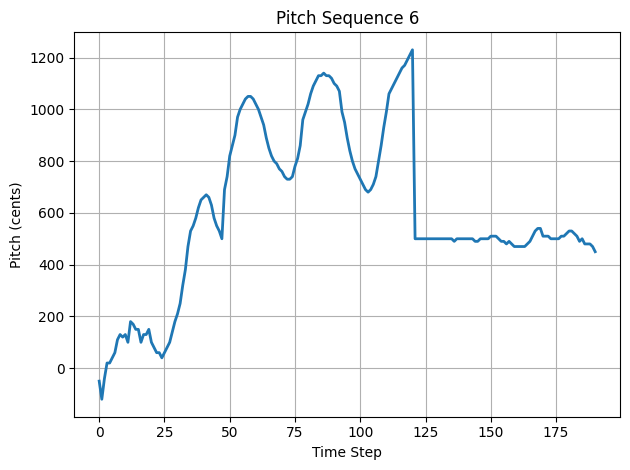

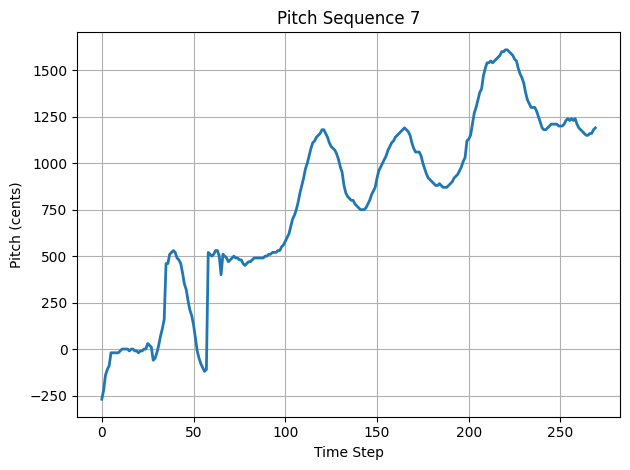

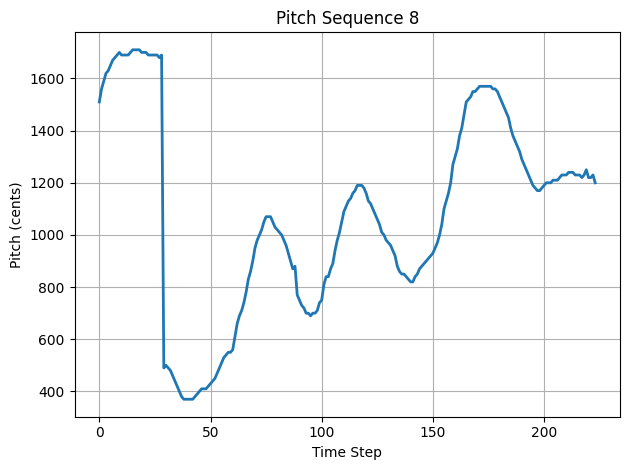

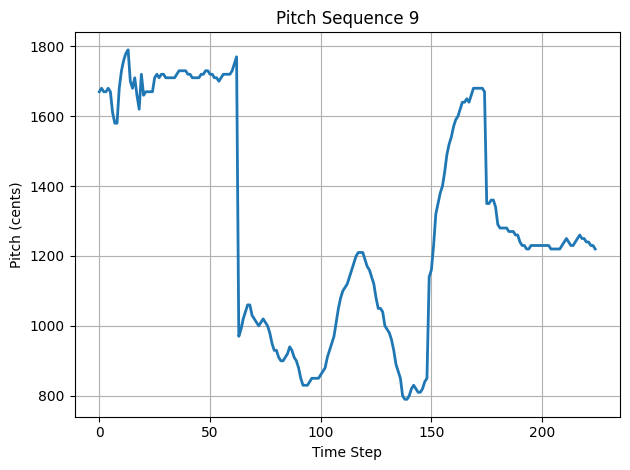

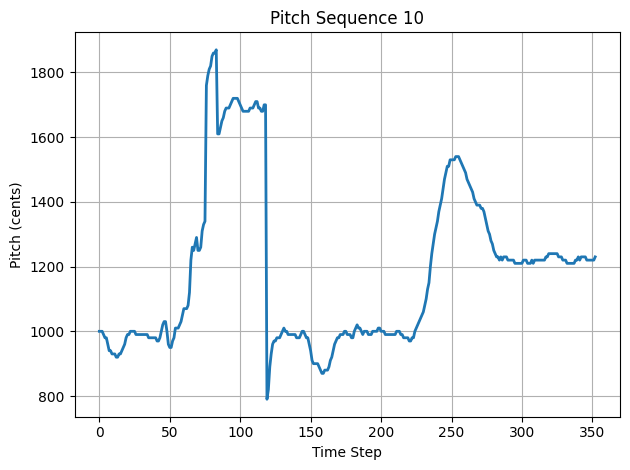

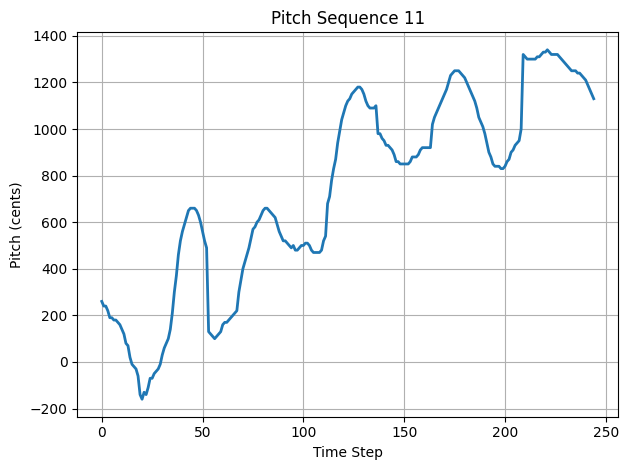

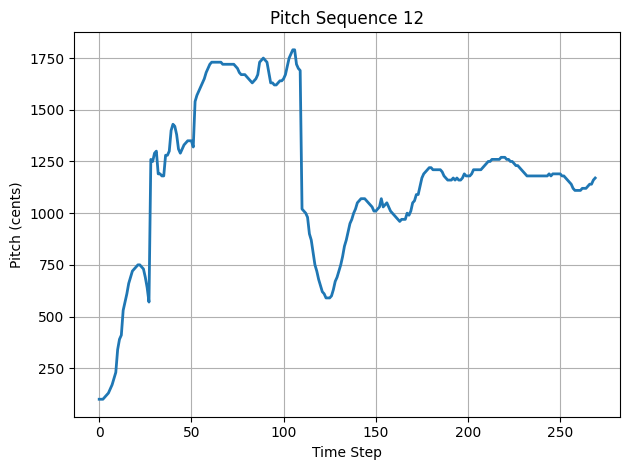

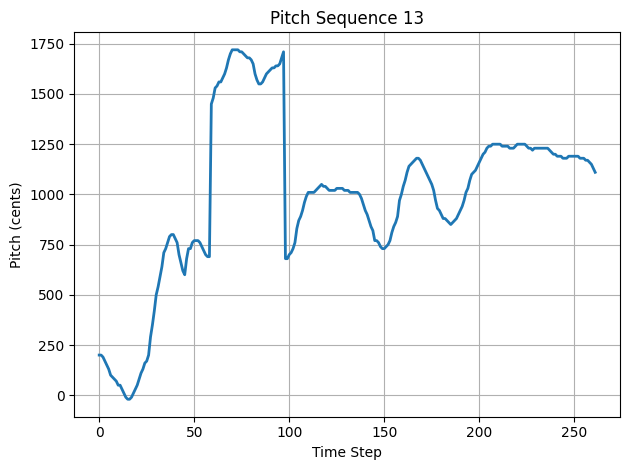

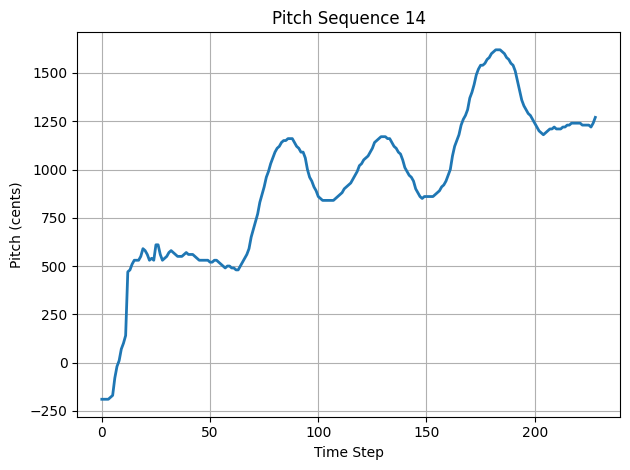

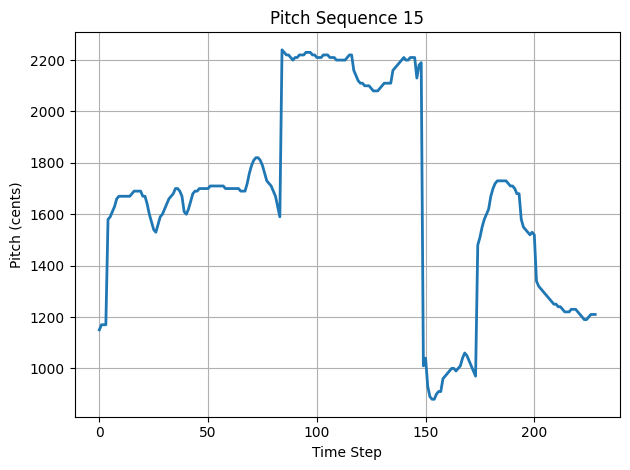

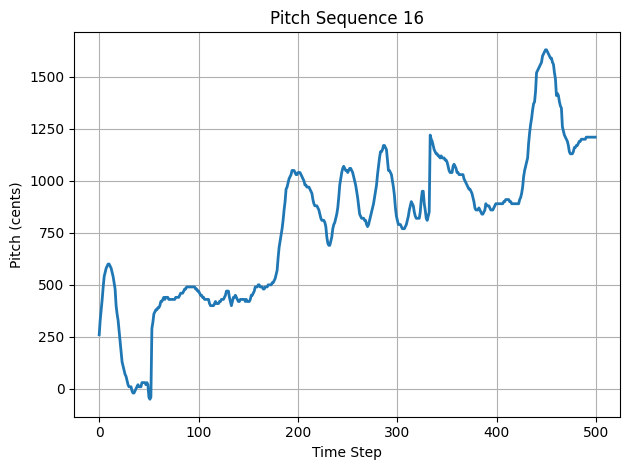

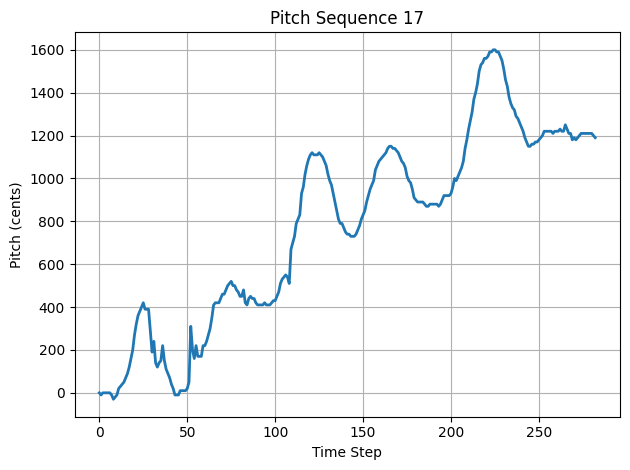

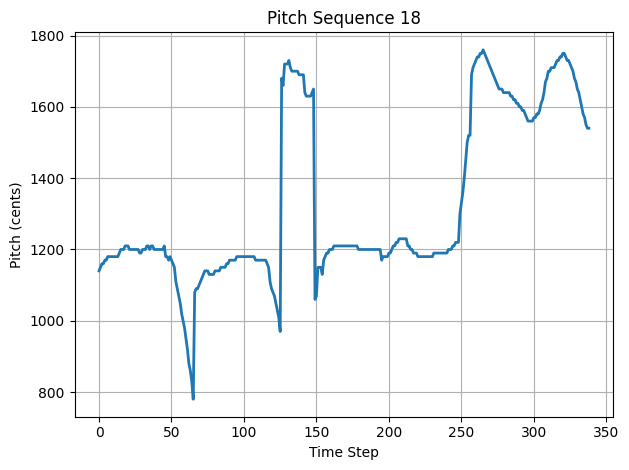

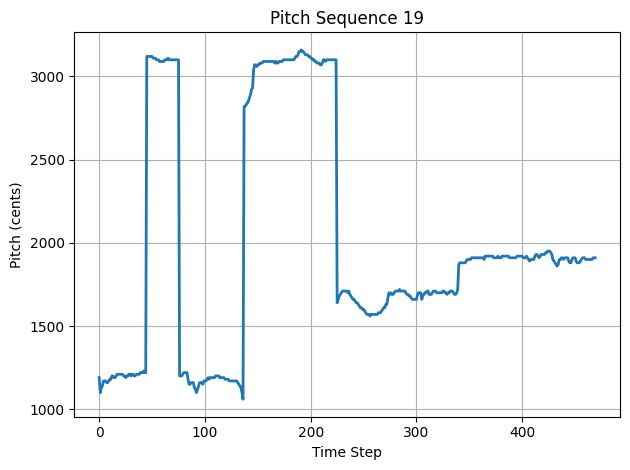

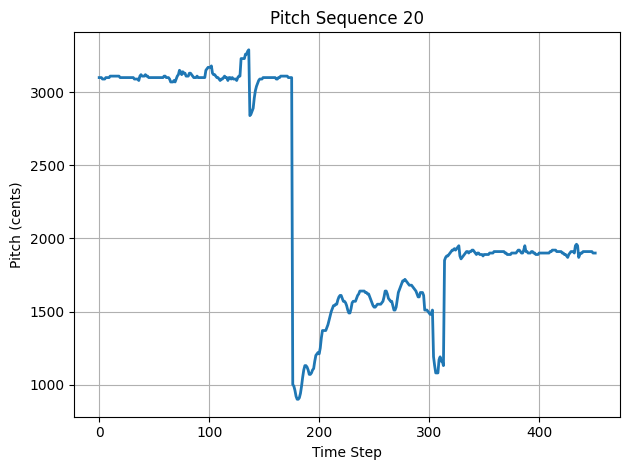

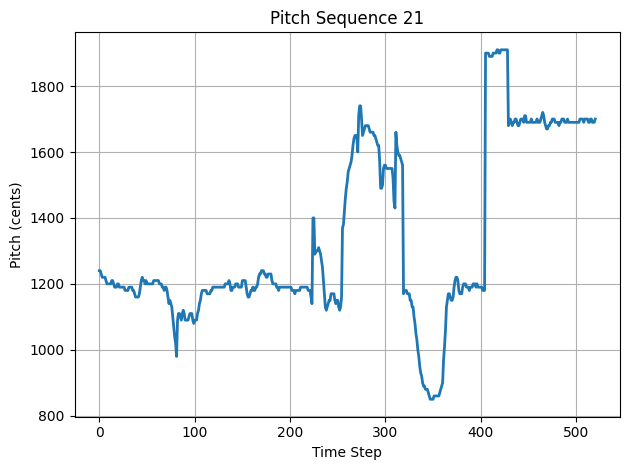

In [ ]:
import json
import matplotlib.pyplot as plt

# Load the JSON file
with open("only_pitch_cents_grouped.json", "r") as file:
    pitch_sequences = json.load(file)

# Loop through each sequence and plot it
for i, sequence in enumerate(pitch_sequences):
    plt.figure()
    plt.plot(sequence, linestyle='-', linewidth=2)  # smooth line without dots
    plt.title(f"Pitch Sequence {i+1}")
    plt.xlabel("Time Step")
    plt.ylabel("Pitch (cents)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
